# Image loading and visualization

This notebook demonstrates how to create, inspect, and visualize detector images using the `ImageCreator`
task and the `DetImage` datamodel. It shows typical workflows: loading raw FITS, inspecting outputs,
combining detectors into a focal plane, and creating a master bias. Each section contains a brief
explanation and the minimal example code you need to reproduce the step.

Imports and setup
 - Import only what is needed for the examples below.
 - Ensure your `PYTHONPATH` includes the project root (or install the package) so imports resolve.
 - Replace the example file paths with paths valid on your machine.

## Example 1: Create images from raw files

Use `ImageCreator` task to convert raw FITS input into high-level `DetImage` objects.

Initializing `ImageCreator` requires a path to a detector configuration file that defines the structure of the raw data and how to parse it.
- Pass a `detector_config` to `ImageCreator` (path to a YAML/JSON file or a Python `dict`) to describe detector geometry and per-output metadata.
- The detector config controls:
  - mapping of data in FITS extensions to detector/outputs of a detector,
  - per-output information and metadata depending on the detector type, e.g. prescan/overscan slices,
  - focal-plane placement

The `run` method of `ImageCreator` accepts the raw data input and produces a dictionary of `DetImage` objects.
- `input_source` accepts a single file, list of files, directory, or glob pattern, OR arrays from buffer
- Optionally provide `identifier_func` to control how files are classified (bias, object, flat, ...)
- Optionally provide `fitsloader_func` to control how raw FITS files are read-in and add custom preprocessing logic
- The return value is a dictionary keyed by image type (e.g. `'object'`, `'bias'`) whose values are lists
  of `DetImage` objects.

In [27]:
from eregion.tasks.imagegen import ImageCreator
from eregion.tasks.custom import load_image_fits_DEIMOS

# Initialize the ImageCreator with the detector configuration.
creator = ImageCreator(detector_config='../src/eregion/configs/detectors/deimos_sci_raw.yaml')
res = creator.run(input_source='../data/deimos/warmdark_allchans.fits',
                  fileloader_func=load_image_fits_DEIMOS)

2026-08-21 12:04:34,889 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci_raw.yaml'
2026-08-21 12:04:34,889 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci_raw.yaml'
2026-08-21 12:04:34,890 - image_creator - INFO - Item ../data/deimos/warmdark_allchans.fits is a regular path string
2026-08-21 12:04:34,890 - image_creator - INFO - Item ../data/deimos/warmdark_allchans.fits is a regular path string


The output of `ImageCreator.run()` is `ImageResult` object (subclass of `TaskResult`, a mappable). All `TaskResult` objects have meta attributes (`params`, `upstream`, `timestamp`) and payload attributes (the actual data). Use its `get_schema()` method to inspect the schema of the result object.

In [28]:
res.get_schema()

{'fields': {'data': 'eregion.datamodels.image.ImageBundle | eregion.datamodels.focalplaneimage.FPImageBundle'},
 'required': ['data'],
 'defaults': {},
 'descriptions': {}}

`ImageBundle` is a simple container for a list of `DetImage` (and other image) objects. Upon init, it creates a dataframe of image_type metadata of the images, and stores it in `list` attribute, images are stored in `.images`, and in `.list["object"]`.
- Images can be accessed by indexing the object, the `getitem`, `setitem` and `iter` dunders are wrapped around the list of images, as well as `append()` and `extend()` methods.
- Wrappers for some pandas dataframe methods are also provided to filter, group the `.list` dataframe.
- `filter()` (returns list of images) and `__call__()` (returns ImageBundle) can be used to select images by supplying string expressions for the pandas `query()` method. For example, column='val1 | val2' will return all rows where column is either val1 or val2.

In [29]:
bundle = res.data
bundle # returns dataframe's representation in notebook

,type,exptime,det_id,filename,object
0,unknown,None,det_1,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
1,unknown,None,det_2,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
2,unknown,None,det_3,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
3,unknown,None,det_4,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
4,unknown,None,det_5,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
5,unknown,None,det_6,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
6,unknown,None,det_7,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
7,unknown,None,det_8,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...


In [30]:
bundle[0] # access 0th image

In [31]:
bundle('det_id == "det_1" | det_id == "det_2"')

,type,exptime,det_id,filename,object
0,unknown,None,det_1,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...
1,unknown,None,det_2,../data/deimos/warmdark_allchans.fits,<eregion.datamodels.image.DetImage object at 0...


Each `DetImage` exposes `.data` (full image array) and `.outputs` (per-amplifier subframes).

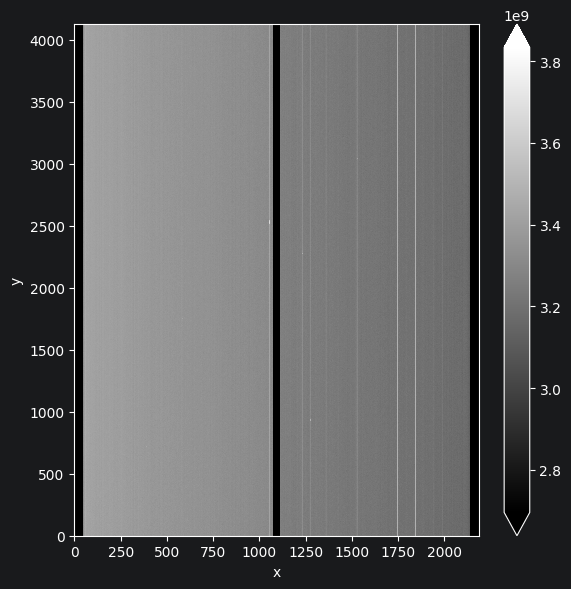

In [32]:
# Display the first DetImage from an input file
det_image = bundle[3]

# Show the DetImage using its built-in show method that takes kwargs for plt.imshow
# For example, to set the colormap to 'gray', and scale the values using vmin, vmax from ZScaleInterval:
from astropy.visualization import ZScaleInterval
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(det_image.data)
ax = det_image.show(cmap='gray', vmin=vmin, vmax=vmax, with_mask=False)

Each `DetImage` contains an `outputs` dict keyed by amplifier id (strings from the detector config).
An `Output` object typically contains:
- `.data`: property to return the amplifier sub-image slice from parent DetImage.data
- Detector-type specific attributes like `.serial_prescan`, `.serial_overscan`, `.parallel_prescan`, `.parallel_overscan`: slices you can set or read in `CCDOutput`

In [33]:
det_image.outputs.keys()

dict_keys(['E4', 'F4'])

In [34]:
det_image.outputs['E4'].parallel_overscan

slice(4105, 4125, 1)

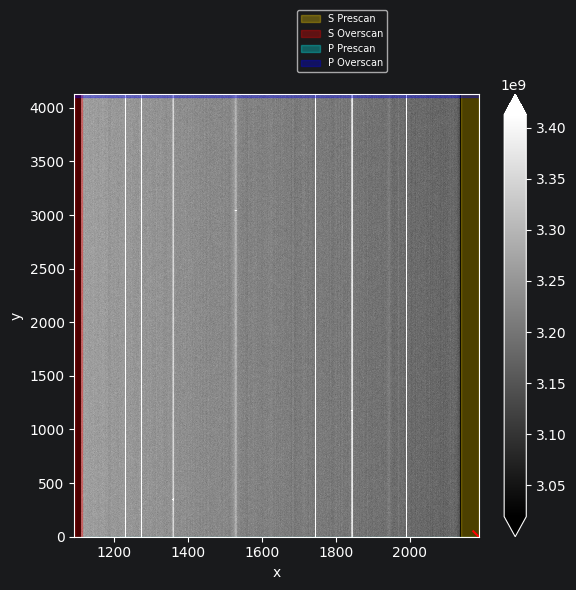

In [36]:
# Plotting the first Output
output = det_image.outputs['F4']
vmin, vmax = interval.get_limits(output.data)

ax = output.show(cmap='gray', vmin=vmin, vmax=vmax, shade_regions=True, origin='lower')

## Building a focal plane image

`FocalPlaneImage` combines multiple `DetImage` instances into a single array representing the focal plane.
- Provide: number of detectors, full dimension (in mm), and the list of `DetImage`s.
- The resulting object contains a consolidated `.data` array and a `.table` describing detector placement.

The DEIMOS raw FITS used above contains 8 extensions, corresponding to 8 detectors in the focal plane, each detector with two outputs.

The focal plane position information needs to be specified in the detector configuration file.

In [37]:
from eregion.datamodels import FocalPlaneImage
fpimage = FocalPlaneImage(num_detectors=8, dim=(4125*2*0.015, 2188*4*0.015), det_images=bundle) # num pixels multiplied by pixel size of 0.015 to set dim

Focal plane usage tips
- Ensure `num_detectors` and `dim` reflect your detector layout.
- Use `table` to verify that detector positions were applied correctly.

In [38]:
fpimage.table

,det_id,x_min,x_max,y_min,y_max,angle,flip_x,flip_y
0,det_1,-4376,-2188,0,4125,0.0,False,True
1,det_2,-2188,0,0,4125,0.0,False,True
2,det_3,0,2188,0,4125,0.0,False,True
3,det_4,2188,4376,0,4125,0.0,False,True
4,det_5,2188,4376,-4125,0,0.0,True,False
5,det_6,0,2188,-4125,0,0.0,True,False
6,det_7,-2188,0,-4125,0,0.0,True,False
7,det_8,-4376,-2188,-4125,0,0.0,True,False


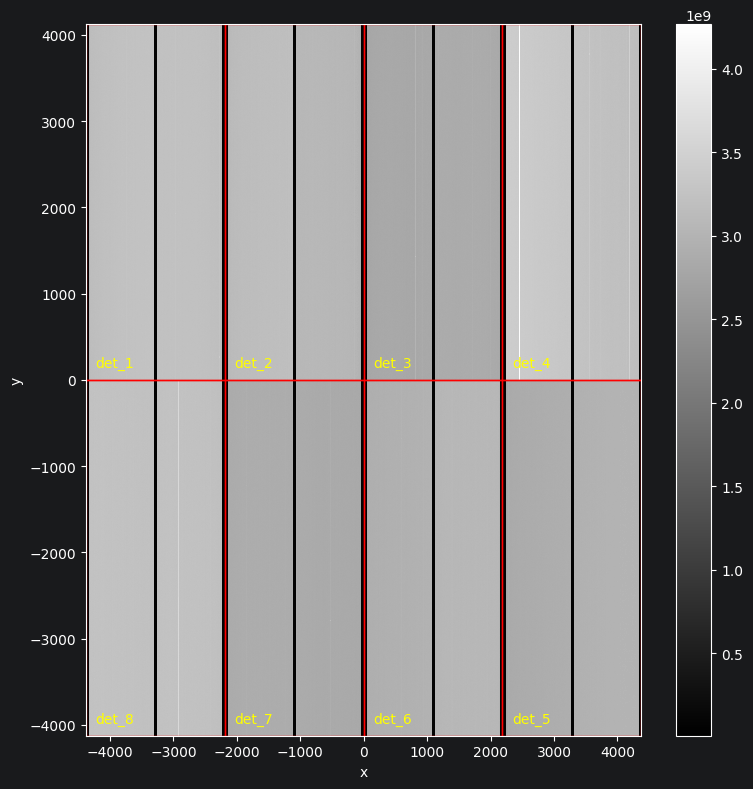

In [42]:
_ = fpimage.show(cmap='gray', show_det_id=True)

## Example 2: Image loading with custom identifier function

In [43]:
from eregion.tasks.imagegen import ImageCreator
creator = ImageCreator(detector_config='../src/eregion/configs/detectors/deimos_sci.yaml')

# load custom identifier function to identify bias frames based on filename, supply as identifier_func to ImageCreator.run
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
res = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS, fileloader_func=load_image_fits_DEIMOS)

2026-08-21 12:08:26,202 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-08-21 12:08:26,202 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-08-21 12:08:26,202 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-08-21 12:08:26,203 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits is a glob pattern
2026-08-21 12:08:26,203 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits is a glob pattern
2026-08-21 12:08:26,203 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits is a glob pattern


Check the result ImageBundle to confirm bias images were identified and loaded correctly.

In [44]:
bundle = res.data
bundle

,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object
0,bias,0.0,2026-05-27T155929.184,0,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,bias,0.0,2026-05-27T160054.183,1,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,bias,0.0,2026-05-27T160219.181,2,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,bias,0.0,2026-05-27T160344.179,3,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,bias,0.0,2026-05-27T160509.178,4,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,bias,0.0,2026-05-27T155929.184,0,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,bias,0.0,2026-05-27T160054.183,1,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,bias,0.0,2026-05-27T160219.181,2,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
8,bias,0.0,2026-05-27T160344.179,3,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
9,bias,0.0,2026-05-27T160509.178,4,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


2026-08-21 12:09:10,093 - eregion.datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


<Axes: xlabel='x', ylabel='y'>

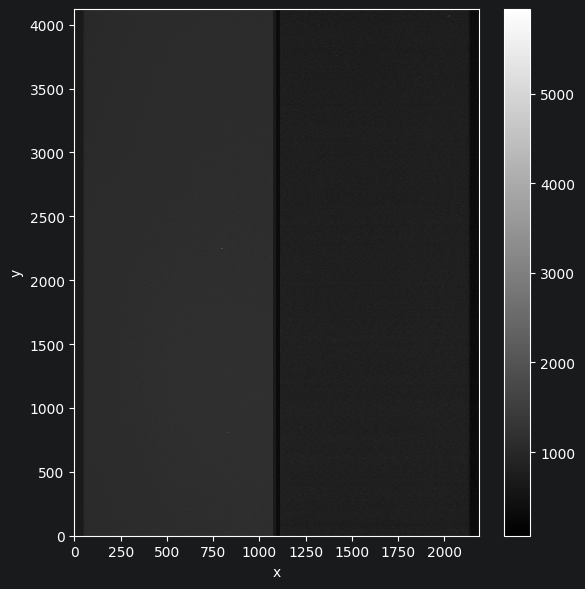

In [45]:
bundle[0].show(cmap='gray')

## Example 3: Create master bias using tasks directly in the notebook

Use the `MasterBias` task to combine many bias frames into a single master bias frame.
- Typical method: `'median'` or `'mean'`.
- Input: a list of `DetImage` objects or `ImageBundle` of bias type.
- Output: `CalibrationResult` object containing master bias frames in `master_bias` attribute.
- Inspect the result and visualize with the same `show()` helpers.

In [46]:
from eregion.tasks.calibration import MasterBias
# To get the list of available methods for any task, use Task.print_methods()
MasterBias().print_methods()

2026-08-21 12:09:56,366 - MasterBias - INFO - Available methods for MasterBias:
2026-08-21 12:09:56,367 - MasterBias - INFO - - median: <function median_combine at 0x1151c4220>, (images: list[numpy.ndarray]) -> numpy.ndarray


In [47]:
# Create master bias task and run it
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(images=bundle('type == "bias"'))

2026-08-21 12:10:39,558 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-08-21 12:10:39,558 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-08-21 12:10:40,045 - MasterBias - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-05-27T155929.184', 'seqnum': 0, 'led': 'None', 'backbias': '0.0'}
2026-08-21 12:10:40,045 - MasterBias - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-05-27T155929.184', 'seqnum': 0, 'led': 'None', 'backbias': '0.0'}
2026-08-21 12:10:40,491 - MasterBias - INFO - Created master calibration frame for det_id: det_2, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-05-27T155929.184', 'seqnum': 0, 'led': 'None', 'backbias': '0.0'}
2026-08-21 12:10:40,491 - MasterBias - INFO - Created master calibration frame for det_id: det_2, type: {'type': 'master_bias', 'exptime'

In [48]:
mb_res.master_bias

,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object
0,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,master_bias,0.0,2026-05-27T155929.184,0,None,0.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


2026-08-21 12:11:10,150 - eregion.datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


<Axes: xlabel='x', ylabel='y'>

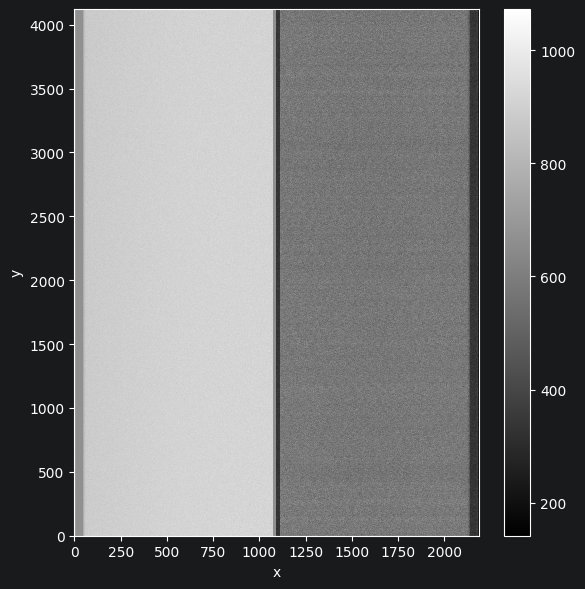

In [49]:
mb_res.master_bias[0].show(cmap='gray')